# GraphRAG Output Explorer

Explore the knowledge graph produced by `uv run python main.py index`.

**Tables available:**
- `entities` — extracted named entities (101 rows)
- `relationships` — connections between entities (173 rows)
- `communities` — Leiden clusters (24 rows)
- `community_reports` — LLM-generated narrative summaries (24 rows)
- `text_units` — source text chunks (4 rows)
- `documents` — original input files (4 rows)

In [7]:
import pandas as pd
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_rows", 100)

OUT = Path("output")

entities = pd.read_parquet(OUT / "entities.parquet")
relationships = pd.read_parquet(OUT / "relationships.parquet")
communities = pd.read_parquet(OUT / "communities.parquet")
reports = pd.read_parquet(OUT / "community_reports.parquet")
text_units = pd.read_parquet(OUT / "text_units.parquet")
documents = pd.read_parquet(OUT / "documents.parquet")

print(f"Entities: {len(entities)}, Relationships: {len(relationships)}")
print(f"Communities: {len(communities)}, Reports: {len(reports)}")
print(f"Text units: {len(text_units)}, Documents: {len(documents)}")

Entities: 101, Relationships: 173
Communities: 24, Reports: 24
Text units: 4, Documents: 4


---
## 1. Entities

Each entity has a `title`, `type`, `description`, `degree` (number of connections), and `frequency` (how many text units mention it).

In [8]:
entities[["title", "type", "description", "degree", "frequency"]].sort_values(
    "degree", ascending=False
).head(20)

,title,type,description,degree,frequency
0,APOLLO PROGRAM,EVENT,The Apollo Program was NASA's ambitious spaceflight program that operated from 1961 to 1972 with the primary objecti...,30,4
30,MOON,GEO,The Moon is a celestial body that served as the primary target destination for NASA's Apollo program. This natural s...,23,2
66,ARTEMIS PROGRAM,EVENT,NASA space program announced in 2017 that aims to return humans to the Moon by the mid-2020s and establish sustainab...,10,1
1,NASA,ORGANIZATION,NASA (National Aeronautics and Space Administration) is the United States' premier space agency responsible for civi...,10,3
37,APOLLO 13,EVENT,"Lunar mission launched on April 11, 1970, that became a successful failure due to oxygen tank explosion forcing miss...",9,1
21,APOLLO 11,EVENT,"Apollo 11 was the historic spaceflight mission that achieved the first human landing on the Moon on July 20, 1969. T...",8,3
54,APOLLO 17,EVENT,"Apollo 17 was the final Apollo mission in NASA's lunar exploration program, launched on December 7, 1972. This histo...",7,2
46,APOLLO 15,EVENT,"First extended scientific expedition to the Moon launched on July 26, 1971, featuring the first Lunar Roving Vehicle",7,1
32,APOLLO 12,EVENT,"Lunar mission launched on November 14, 1969, that demonstrated precision landing capability by touching down near Su...",7,1
19,JIM LOVELL,PERSON,Jim Lovell is a distinguished American astronaut who played crucial roles in two of NASA's most significant Apollo m...,6,2


<Axes: title={'center': 'Entity Types'}, xlabel='type'>

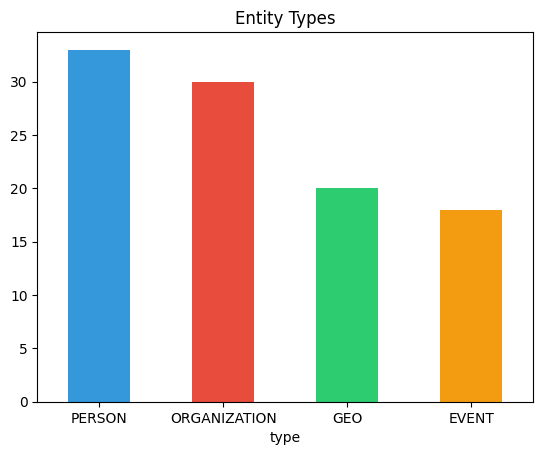

In [9]:
# Entity type distribution
entities["type"].value_counts().plot.bar(title="Entity Types", rot=0, color=["#3498db", "#e74c3c", "#2ecc71", "#f39c12"])

<Axes: title={'center': 'Top 15 Entities by Degree'}, ylabel='title'>

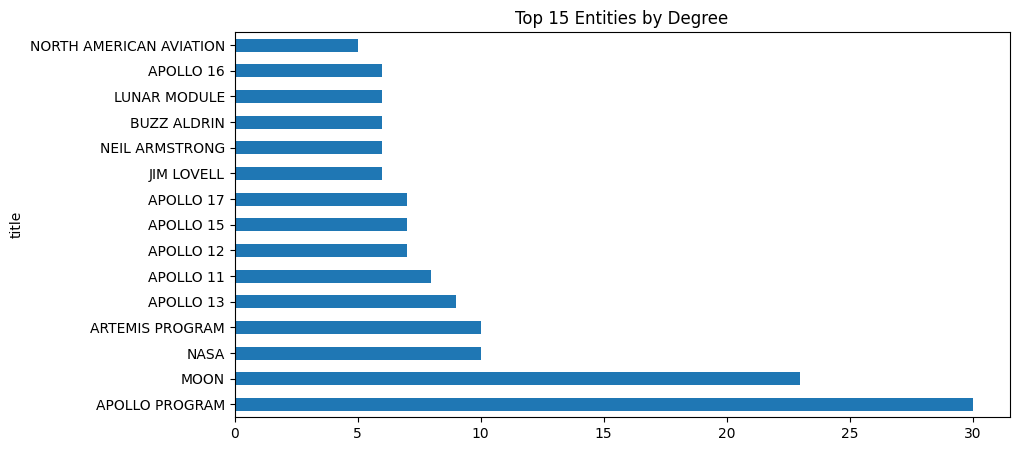

In [10]:
# Degree distribution — who are the most connected entities?
top = entities.nlargest(15, "degree")
top.plot.barh(x="title", y="degree", title="Top 15 Entities by Degree", legend=False, figsize=(10, 5))

---
## 2. Relationships

Each relationship links a `source` entity to a `target` entity with a `description`, `weight`, and `combined_degree`.

In [11]:
relationships[["source", "target", "description", "weight", "combined_degree"]].sort_values(
    "weight", ascending=False
).head(20)

,source,target,description,weight,combined_degree
29,APOLLO PROGRAM,MOON,The Apollo Program was a comprehensive space exploration initiative specifically designed with the primary objective...,28.0,53
53,HOUSTON,TEXAS,Houston is a city that is located in the state of Texas. Both descriptions consistently identify Houston as being si...,19.0,4
15,WILLIAM ANDERS,APOLLO 8,"William Anders was an astronaut who served on the historic Apollo 8 mission. During this groundbreaking spaceflight,...",19.0,8
112,MANNED SPACECRAFT CENTER,HOUSTON,"The Manned Spacecraft Center is located in Houston, Texas. This facility serves as a key installation for space oper...",17.0,6
5,WERNHER VON BRAUN,MARSHALL SPACE FLIGHT CENTER,Wernher von Braun worked at the Marshall Space Flight Center where he served in a leadership capacity directing the ...,17.0,10
3,NORTH AMERICAN AVIATION,APOLLO PROGRAM,"North American Aviation served as a major contractor for the Apollo Program, playing a crucial role in the United St...",16.0,35
0,APOLLO PROGRAM,NASA,NASA was responsible for managing the Apollo Program,10.0,40
25,LUNAR MODULE EAGLE,APOLLO 11,Eagle was the Lunar Module used in Apollo 11,10.0,11
19,APOLLO 11,SEA OF TRANQUILITY,Apollo 11 landed on the Sea of Tranquility on the Moon,10.0,9
23,COMMAND AND SERVICE MODULE,NORTH AMERICAN AVIATION,North American Aviation built the Command and Service Module,10.0,6


<Axes: title={'center': 'Relationship Weight Distribution'}, ylabel='Frequency'>

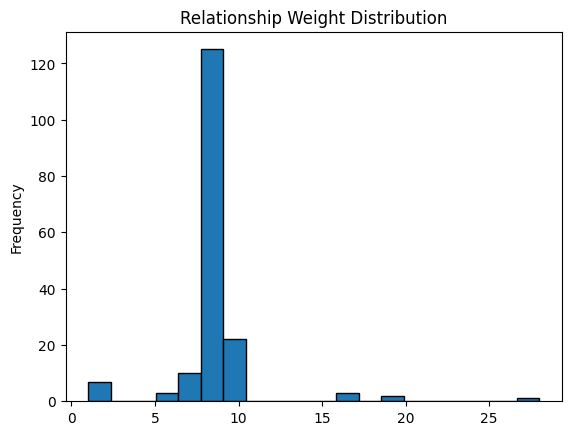

In [12]:
# Weight distribution
relationships["weight"].plot.hist(bins=20, title="Relationship Weight Distribution", edgecolor="black")

<Axes: title={'center': 'Most Referenced Entities in Relationships'}>

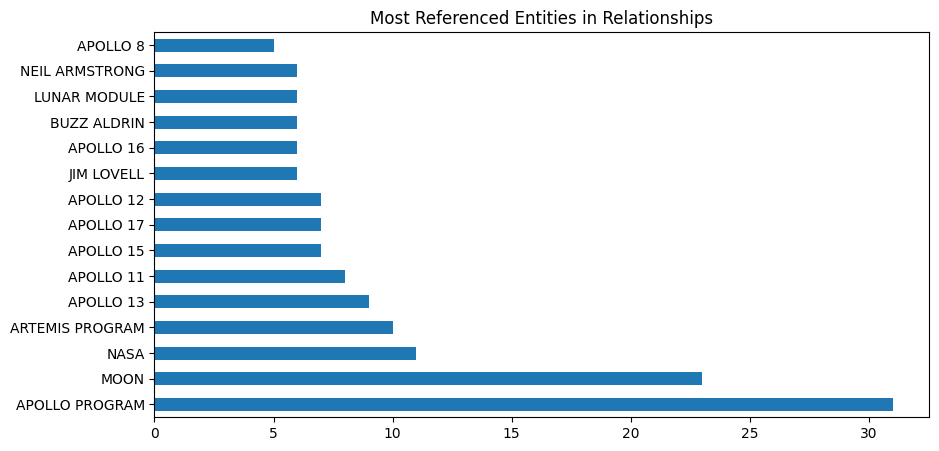

In [13]:
# Which entities appear most often as source or target?
all_mentions = pd.concat([relationships["source"], relationships["target"]])
all_mentions.value_counts().head(15).plot.barh(title="Most Referenced Entities in Relationships", figsize=(10, 5))

---
## 3. Communities

Entities are clustered into communities using the Leiden algorithm. Communities form a hierarchy — level 0 is the coarsest.

In [14]:
communities[["community", "level", "title", "size", "parent"]].sort_values(
    ["level", "size"], ascending=[True, False]
)

,community,level,title,size,parent
6,6,0,Community 6,20,-1
0,0,0,Community 0,18,-1
4,4,0,Community 4,13,-1
7,7,0,Community 7,10,-1
8,8,0,Community 8,8,-1
2,2,0,Community 2,7,-1
5,5,0,Community 5,7,-1
1,1,0,Community 1,5,-1
3,3,0,Community 3,5,-1
13,13,1,Community 13,6,4


In [15]:
# Community size by level
communities.groupby("level")["size"].describe()

,count,mean,std,min,25%,50%,75%,max
level,,,,,,,,
0,9.0,10.333333,5.522681,5.0,7.0,8.0,13.0,20.0
1,15.0,4.066667,1.387015,2.0,3.0,4.0,5.0,6.0


In [16]:
# Which entities belong to the largest community?
largest = communities.sort_values("size", ascending=False).iloc[0]
print(f"Largest community: {largest['title']} (level {largest['level']}, {largest['size']} entities)")

member_ids = largest["entity_ids"]
entities[entities["id"].isin(member_ids)][["title", "type", "degree"]].sort_values("degree", ascending=False)

Largest community: Community 6 (level 0, 20 entities)


,title,type,degree
0,APOLLO PROGRAM,EVENT,30
27,LUNAR MODULE,ORGANIZATION,6
4,NORTH AMERICAN AVIATION,ORGANIZATION,5
87,GRUMMAN,ORGANIZATION,3
31,EARTH,GEO,3
58,SERVICE MODULE,ORGANIZATION,3
62,SPACE RACE,EVENT,3
61,SOVIET UNION,GEO,2
88,BETHPAGE,GEO,2
85,DOWNEY,GEO,2


---
## 4. Community Reports

LLM-generated narrative summaries of each community. Each report has a `title`, `summary`, `rank` (impact score), and structured `findings`.

In [17]:
reports[["community", "level", "title", "rank", "summary"]].sort_values(
    "rank", ascending=False
).head(10)

,community,level,title,rank,summary
23,8,0,Apollo 11 Mission Community,9.5,This community centers around the historic Apollo 11 mission and its key participants. The community includes the th...
21,6,0,Apollo Program and NASA Space Exploration Community,9.5,"This community centers around NASA's Apollo Program (1961-1972), one of humanity's most significant space exploratio..."
15,0,0,Apollo Program Lunar Exploration Community,9.5,"This community represents NASA's Apollo program lunar exploration network, centered around the Moon as the primary d..."
1,10,1,Apollo 14 Moon Mission Community,8.5,"This community centers around the Apollo 14 lunar mission, which launched on January 31, 1971, and successfully achi..."
22,7,0,NASA Houston Space Operations Community,8.5,"This community represents the core infrastructure of NASA's human spaceflight operations centered in Houston, Texas...."
20,5,0,Wernher von Braun and Marshall Space Flight Center Space Program Community,8.5,"This community centers around Wernher von Braun, a German-born rocket engineer who transitioned from developing the ..."
19,4,0,NASA Artemis Program and International Lunar Exploration Community,8.5,"This community centers around NASA's Artemis program, a comprehensive lunar exploration initiative announced in 2017..."
18,3,0,Apollo 15 Mission Community,8.5,"This community centers around the historic Apollo 15 mission, the first extended scientific expedition to the Moon l..."
17,2,0,Apollo 8 and Apollo 13 Mission Community,8.5,This community centers around two landmark NASA missions - Apollo 8 and Apollo 13 - and their associated astronauts....
16,1,0,MIT Apollo Guidance Computer Development Community,8.5,This community centers around the development of the Apollo Guidance Computer at MIT and its Instrumentation Laborat...


In [18]:
# Read the top-ranked community report in full
top_report = reports.sort_values("rank", ascending=False).iloc[0]
print(f"=== {top_report['title']} (rank: {top_report['rank']}) ===")
print()
print(top_report["full_content"])

=== Apollo 11 Mission Community (rank: 9.5) ===

# Apollo 11 Mission Community

This community centers around the historic Apollo 11 mission and its key participants. The community includes the three astronauts - Neil Armstrong (commander), Buzz Aldrin (Lunar Module Pilot), and Michael Collins (Command Module Pilot) - along with the mission itself, the Lunar Module Eagle that carried Armstrong and Aldrin to the lunar surface, and the Sea of Tranquility landing site. The community also encompasses related figures such as President Richard Nixon who honored the astronauts, and extends to future space exploration advocacy, particularly Buzz Aldrin's promotion of Mars exploration. This represents one of humanity's greatest achievements in space exploration and continues to influence future space endeavors.

## Neil Armstrong's central leadership role and humble character

Neil Armstrong served as the commander of Apollo 11 and achieved the historic distinction of being the first human to s

<Axes: title={'center': 'Community Report Impact Ratings'}, ylabel='Frequency'>

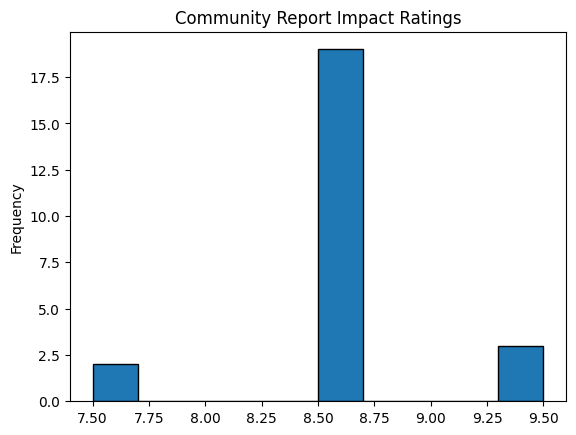

In [19]:
# Impact rating distribution
reports["rank"].plot.hist(bins=10, title="Community Report Impact Ratings", edgecolor="black")

---
## 5. Text Units

The original documents split into chunks. Each text unit tracks which entities and relationships it contains.

In [20]:
text_units[["human_readable_id", "n_tokens", "document_id"]].merge(
    documents[["id", "title"]].rename(columns={"id": "document_id"}),
    on="document_id",
    how="left",
)

,human_readable_id,n_tokens,document_id,title
0,0,426,6f51438faffcaa01448c46a96fa1c90dab9623dbbb63bfbe4db8813ae84a41ee8e53b8feffc5dfb1d89d31877e9dcdfa3099861d54cd63636207...,apollo_program_overview.txt
1,1,401,3549bb0ef19b0b45493f6fa077a298d7e498a7d47c352b0271adbeec33827b419c2ff5f00392c398d0f0b775f3c9c2a6be5c800bc8ccf4391c6a...,apollo_missions.txt
2,2,415,4f0f65796bccf7a95bdf2969da83af426406e1efb39fca53a62d5e4f5c48b7746a2e48a4045d6db39eb56b528a0b1424777d734d10e7606fef91...,apollo_legacy.txt
3,3,411,0135e7d6044f0c25f0540cc19bd2c633d1d84904cc3aac7dd288a2ff18d759d720c0b7df603e4204942667b4b99755ee88f5dc1fd48ba164867e...,apollo_technology.txt


In [36]:
# How many entities were extracted per text unit?
text_units["n_entities"] = text_units["entity_ids"].apply(lambda x: len(x) if x.any() else 0)
text_units["n_relationships"] = text_units["relationship_ids"].apply(lambda x: len(x) if x.any() else 0)

text_units[["human_readable_id", "n_tokens", "n_entities", "n_relationships"]]

,human_readable_id,n_tokens,n_entities,n_relationships
0,0,426,32,41
1,1,401,33,65
2,2,415,33,35
3,3,411,29,40


---
## 6. Graph Overview with NetworkX

Build a NetworkX graph from the parquet data and compute basic statistics.

In [22]:
import networkx as nx

G = nx.DiGraph()

for _, row in entities.iterrows():
    G.add_node(row["title"], type=row["type"], degree=row["degree"])

for _, row in relationships.iterrows():
    G.add_edge(row["source"], row["target"], weight=row["weight"])

print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")
print(f"Density: {nx.density(G):.4f}")
print(f"Connected components (undirected): {nx.number_connected_components(G.to_undirected())}")
print(f"Average clustering coefficient: {nx.average_clustering(G.to_undirected()):.4f}")

Nodes: 103
Edges: 173
Density: 0.0165
Connected components (undirected): 4
Average clustering coefficient: 0.3660


<Axes: title={'center': 'Top 15 Entities by PageRank'}, ylabel='Entity'>

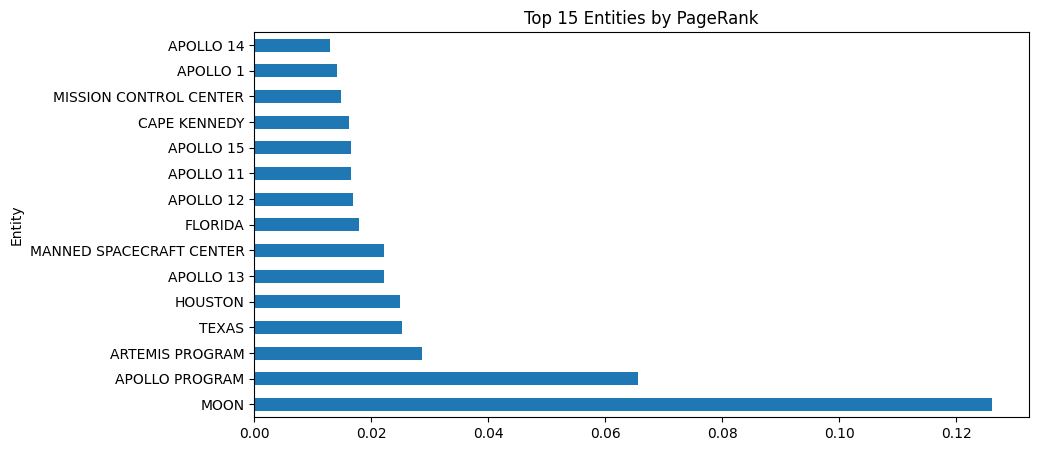

In [27]:
# PageRank — which entities are most "important" by graph structure?
pr = nx.pagerank(G, weight="weight")
top_pr = sorted(pr.items(), key=lambda x: x[1], reverse=True)[:15]

pd.DataFrame(top_pr, columns=["Entity", "PageRank"]).plot.barh(
    x="Entity", y="PageRank", title="Top 15 Entities by PageRank", legend=False, figsize=(10, 5)
)

---
## 7. Explore a Specific Entity

Pick an entity and see all its relationships and community membership.

In [24]:
ENTITY = "NASA"  # Change this to explore a different entity

# Entity details
entity_row = entities[entities["title"] == ENTITY].iloc[0]
print(f"Entity: {entity_row['title']}")
print(f"Type: {entity_row['type']}")
print(f"Degree: {entity_row['degree']}")
print(f"Frequency: {entity_row['frequency']}")
print(f"\nDescription: {entity_row['description']}")

# Relationships involving this entity
print(f"\n--- Relationships ---")
rels = relationships[
    (relationships["source"] == ENTITY) | (relationships["target"] == ENTITY)
][["source", "target", "description", "weight"]].sort_values("weight", ascending=False)
rels

Entity: NASA
Type: ORGANIZATION
Degree: 10
Frequency: 3

Description: NASA (National Aeronautics and Space Administration) is the United States' premier space agency responsible for civilian space exploration and aeronautics research. The organization has played a pivotal role in human spaceflight throughout multiple decades, demonstrating consistent leadership in lunar exploration initiatives.

NASA achieved remarkable success through its management and execution of the Apollo program, a historic lunar exploration initiative that accomplished multiple successful moon landing missions. This program established NASA as a leading force in space exploration and demonstrated humanity's capability to reach and explore celestial bodies beyond Earth.

Building upon its Apollo program legacy, NASA announced the Artemis program in 2017, marking a renewed commitment to lunar exploration and establishing ambitious goals for returning humans to the Moon. This modern initiative represents NASA's co

,source,target,description,weight
0,APOLLO PROGRAM,NASA,NASA was responsible for managing the Apollo Program,10.0
41,NASA,APOLLO 11,NASA conducted the successful Apollo 11 mission that preceded the other lunar missions,9.0
42,NASA,APOLLO 12,NASA conducted the Apollo 12 lunar landing mission,9.0
47,NASA,APOLLO 13,NASA conducted the Apollo 13 mission that became a successful failure,9.0
54,NASA,APOLLO 14,NASA conducted the Apollo 14 lunar landing mission,9.0
58,NASA,APOLLO 15,NASA conducted the Apollo 15 extended scientific expedition,9.0
63,NASA,APOLLO 16,NASA conducted the Apollo 16 geological survey mission,9.0
68,NASA,APOLLO 17,"NASA conducted Apollo 17, the final lunar landing mission",9.0
73,NASA,APOLLO PROGRAM,NASA conducted the overall Apollo program with multiple lunar missions,9.0
113,NASA,ARTEMIS PROGRAM,NASA announced and manages the Artemis program,9.0


In [25]:
# Which communities does this entity belong to?
entity_id = entity_row["id"]
member_of = communities[communities["entity_ids"].apply(lambda ids: entity_id in ids)]
member_of[["community", "level", "title", "size"]]

,community,level,title,size
4,4,0,Community 4,13
15,15,1,Community 15,5
